# Задание 3 — AnnotationAgent

**Цель:** агент автоматической разметки данных, генерации спецификации, оценки качества и экспорта в LabelStudio.

**Части:**
- **Часть 1:** Автоматическая разметка (`auto_label`) — гибридный метод (rule-based + TF-IDF zero-shot)
- **Часть 2:** Спецификация разметки (`generate_spec`) — Markdown с классами, примерами, граничными случаями
- **Часть 3:** Оценка качества (`check_quality`) — Cohen's κ, распределение меток, confidence
- **Часть 4:** Экспорт в LabelStudio (`export_to_labelstudio`) — JSON-файл
- **Часть 5:** Сравнение с ручной разметкой однокурсника
- **Бонус:** Human-in-the-loop — экспорт low-confidence примеров для ручной доразметки

In [1]:
import sys
import os
sys.path.insert(0, os.path.join('..', 'agents'))

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.family'] = 'DejaVu Sans'

from annotation_agent import AnnotationAgent, QualityMetrics, AnnotationSpec

print('Импорты выполнены успешно')

Импорты выполнены успешно


---
## Загрузка данных

In [2]:
df = pd.read_csv(os.path.join('..', 'data', 'raw', 'legal_corpus_with_titles.csv'))
print(f'Загружено: {df.shape[0]} строк, {df.shape[1]} колонок')
print(f'Колонки: {list(df.columns)}')
print(f'\nРаспределение по кодексам:')
display(df['Название нормативно-правового акта'].value_counts())
df.head(3)

Загружено: 10343 строк, 3 колонок
Колонки: ['content', 'metadata', 'Название нормативно-правового акта']

Распределение по кодексам:


Название нормативно-правового акта
Отдельный нормативно-правовой акт    2963
ГК РФ                                1480
КоАП РФ                              1130
НК РФ                                 823
УПК РФ                                559
ТК РФ                                 539
УК РФ                                 534
ГПК РФ                                498
БК РФ                                 441
АПК РФ                                406
ЖК РФ                                 243
ЛК РФ                                 215
ЗК РФ                                 193
СК РФ                                 177
ГрК РФ                                142
Name: count, dtype: int64

,content,metadata,Название нормативно-правового акта
0,Статья 1. Осуществление правосудия арбитражным...,{'Название нормативно-правового акта': 'АПК РФ...,АПК РФ
1,Статья 2. Задачи судопроизводства в арбитражны...,{'Название нормативно-правового акта': 'АПК РФ...,АПК РФ
2,Статья 3. Законодательство о судопроизводстве ...,{'Название нормативно-правового акта': 'АПК РФ...,АПК РФ


---
## Часть 1: Автоматическая разметка (auto_label)

In [3]:
# Инициализируем агента
agent = AnnotationAgent(modality='text', confidence_threshold=0.55)

AnnotationAgent инициализирован (modality=text, threshold=0.55)


In [4]:
# Автоматическая разметка гибридным методом
df_labeled = agent.auto_label(df, text_column='content', method='hybrid')


auto_label: разметка 10343 документов (метод=hybrid)

Результаты:
  Всего размечено: 10343
  Средняя уверенность: 0.294
  Низкая уверенность (<0.55): 9339 (90.3%)

  Распределение меток:
    ГК РФ: 1943 (18.8%)
    Отдельный нормативно-правовой акт: 1549 (15.0%)
    КоАП РФ: 1499 (14.5%)
    НК РФ: 739 (7.1%)
    ТК РФ: 737 (7.1%)
    БК РФ: 697 (6.7%)
    ГПК РФ: 520 (5.0%)
    АПК РФ: 486 (4.7%)
    УК РФ: 451 (4.4%)
    ЗК РФ: 354 (3.4%)
    ЖК РФ: 346 (3.3%)
    УПК РФ: 339 (3.3%)
    СК РФ: 290 (2.8%)
    ГрК РФ: 222 (2.1%)
    ЛК РФ: 171 (1.7%)


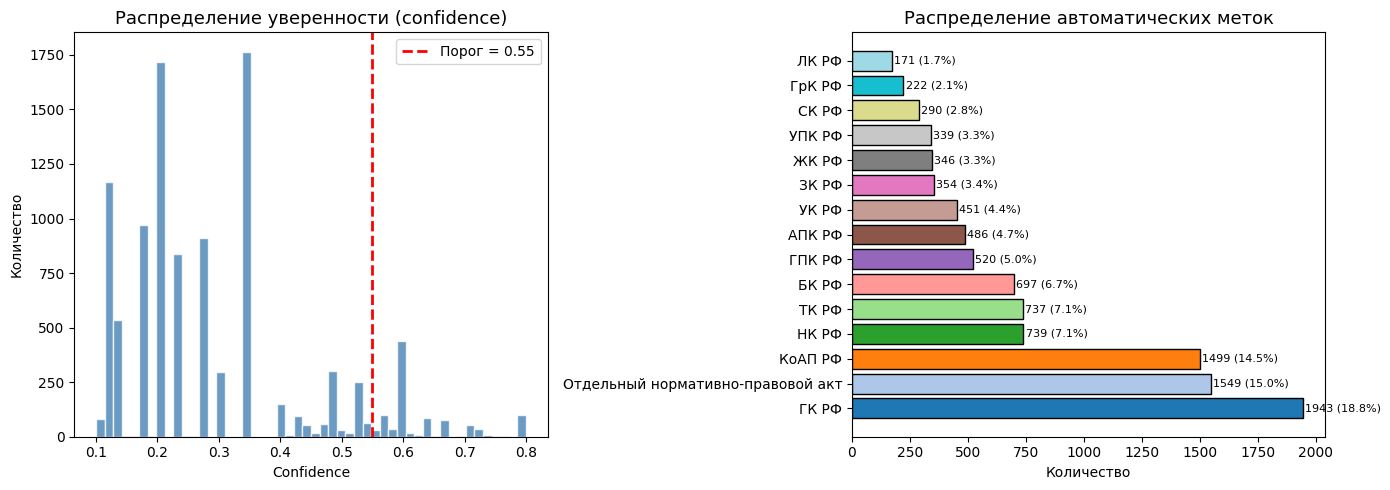

In [5]:
# Визуализация: распределение confidence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма confidence
axes[0].hist(df_labeled['confidence'], bins=50, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(agent.confidence_threshold, color='red', linestyle='--', linewidth=2,
                label=f'Порог = {agent.confidence_threshold}')
axes[0].set_title('Распределение уверенности (confidence)', fontsize=13)
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Количество')
axes[0].legend()

# Распределение меток
label_counts = df_labeled['auto_label'].value_counts()
colors = plt.cm.tab20(np.linspace(0, 1, len(label_counts)))
bars = axes[1].barh(label_counts.index, label_counts.values, color=colors, edgecolor='black')
for bar, val in zip(bars, label_counts.values):
    axes[1].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                 f'{val} ({val/len(df_labeled)*100:.1f}%)', va='center', fontsize=8)
axes[1].set_title('Распределение автоматических меток', fontsize=13)
axes[1].set_xlabel('Количество')

plt.tight_layout()
plt.show()

In [6]:
# Сравнение авторазметки с истинными метками (из датасета)
# В нашем датасете есть колонка 'Название нормативно-правового акта' — это ground truth
TRUE_LABEL_COL = 'Название нормативно-правового акта'

match = (df_labeled['auto_label'] == df_labeled[TRUE_LABEL_COL]).mean() * 100
print(f'Точность авторазметки (совпадение с ground truth): {match:.1f}%')

# Confusion-подобная таблица: авторазметка vs ground truth
cross = pd.crosstab(
    df_labeled[TRUE_LABEL_COL],
    df_labeled['auto_label'],
    margins=True
)
print('\nТаблица сопряженности (строки=ground truth, столбцы=auto_label):')
display(cross)

Точность авторазметки (совпадение с ground truth): 57.2%

Таблица сопряженности (строки=ground truth, столбцы=auto_label):


auto_label,АПК РФ,БК РФ,ГК РФ,ГПК РФ,ГрК РФ,ЖК РФ,ЗК РФ,КоАП РФ,ЛК РФ,НК РФ,Отдельный нормативно-правовой акт,СК РФ,ТК РФ,УК РФ,УПК РФ,All
Название нормативно-правового акта,,,,,,,,,,,,,,,,
АПК РФ,393,0,3,1,0,0,0,2,0,0,7,0,0,0,0,406
БК РФ,2,294,26,0,0,0,2,5,0,3,109,0,0,0,0,441
ГК РФ,17,13,965,0,24,24,58,5,3,7,302,24,11,1,26,1480
ГПК РФ,17,3,15,425,1,4,0,0,0,1,15,16,1,0,0,498
ГрК РФ,0,1,8,0,102,2,18,0,2,0,8,1,0,0,0,142
ЖК РФ,0,8,25,0,7,177,8,0,0,0,13,1,2,2,0,243
ЗК РФ,0,0,14,0,10,1,135,0,3,0,28,1,1,0,0,193
КоАП РФ,2,5,5,0,5,2,10,1019,0,0,81,0,0,1,0,1130
ЛК РФ,0,4,17,0,6,0,8,1,144,0,35,0,0,0,0,215


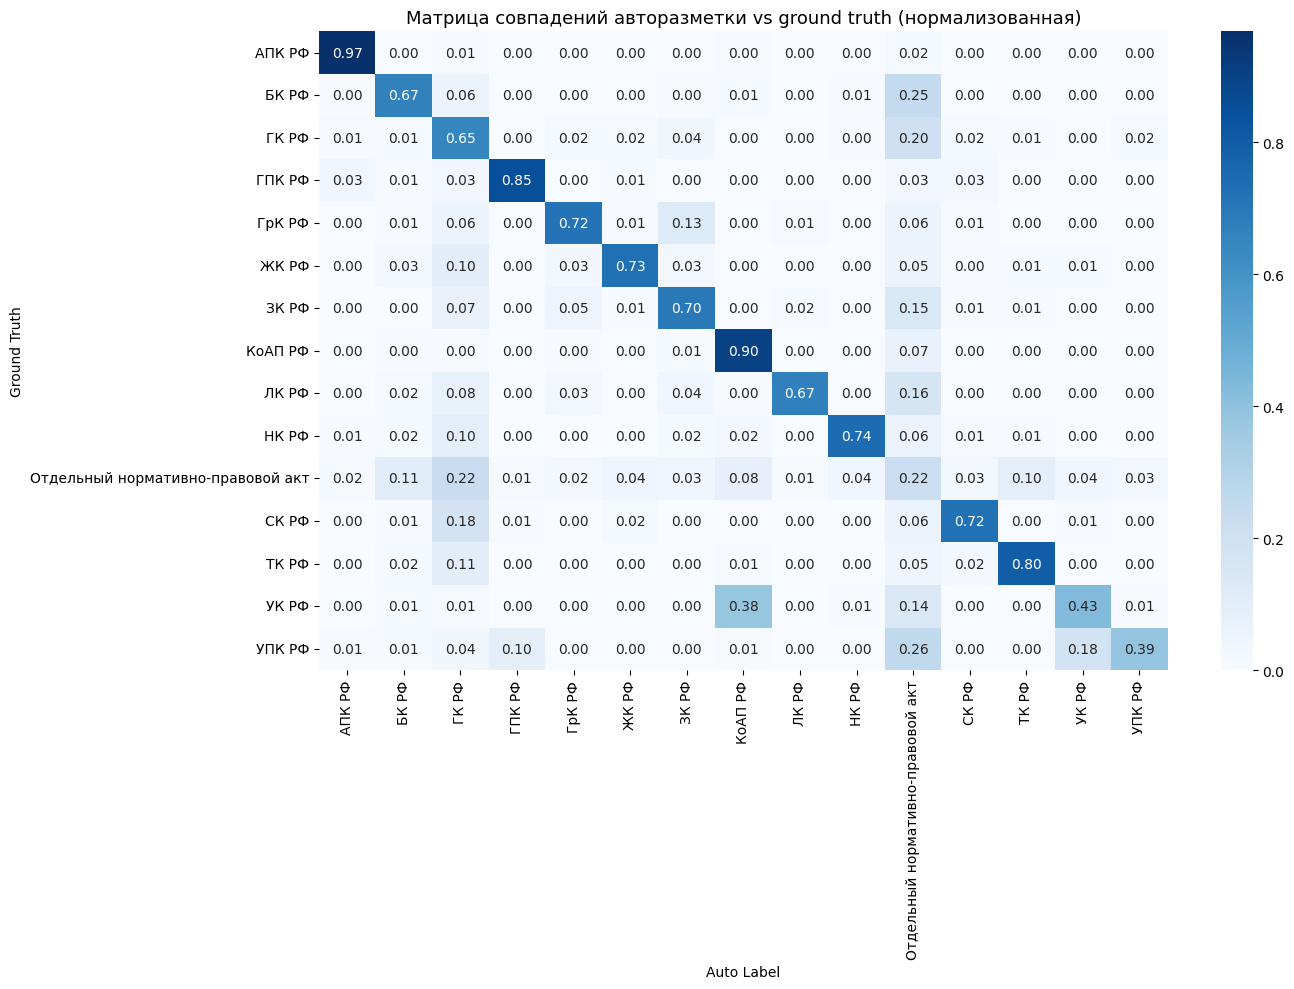

In [7]:
# Визуализация: heatmap accuracy по классам
from sklearn.metrics import confusion_matrix

labels_sorted = sorted(df_labeled[TRUE_LABEL_COL].unique())
cm = confusion_matrix(
    df_labeled[TRUE_LABEL_COL], 
    df_labeled['auto_label'],
    labels=labels_sorted
)

# Нормализуем по строкам (% от истинного класса)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=labels_sorted, yticklabels=labels_sorted, ax=ax)
ax.set_title('Матрица совпадений авторазметки vs ground truth (нормализованная)', fontsize=13)
ax.set_ylabel('Ground Truth')
ax.set_xlabel('Auto Label')
plt.tight_layout()
plt.show()

---
## Часть 2: Спецификация разметки (generate_spec)

In [8]:
spec = agent.generate_spec(
    df_labeled,
    task='document_type_classification',
    text_column='content',
    output_path=os.path.join('..', 'annotation_spec.md')
)

print(f'\nЗадача: {spec.task}')
print(f'Классов: {len(spec.classes)}')
print(f'Примеров: {len(spec.examples)}')
print(f'Граничных случаев: {len(spec.edge_cases)}')


Генерация спецификации разметки: document_type_classification
  Спецификация сохранена: ..\annotation_spec.md
  Классов: 15, примеров: 45, граничных случаев: 5

Задача: document_type_classification
Классов: 15
Примеров: 45
Граничных случаев: 5


In [9]:
# Показываем спецификацию
with open(os.path.join('..', 'annotation_spec.md'), 'r', encoding='utf-8') as f:
    spec_text = f.read()

# Выводим первые 3000 символов
display(Markdown(spec_text[:3000] + '\n\n... (полная версия в annotation_spec.md)'))

# Спецификация разметки

## Задача: document_type_classification

### Описание
Классификация статей нормативно-правовых актов Российской Федерации по принадлежности к кодексу. Каждый текст — одна статья или фрагмент НПА. Необходимо определить, к какому из 15 кодексов (или к категории «Отдельный НПА») относится данный текст.

### Классы разметки

#### АПК РФ
Арбитражный процессуальный кодекс — регулирует судопроизводство в арбитражных судах, экономические споры юридических лиц

#### БК РФ
Бюджетный кодекс — регулирует бюджетные отношения, доходы/расходы бюджета, межбюджетные трансферты

#### ГК РФ
Гражданский кодекс — регулирует гражданско-правовые отношения: сделки, договоры, собственность, обязательства

#### ГПК РФ
Гражданский процессуальный кодекс — регулирует гражданское судопроизводство, иски, апелляции

#### ГрК РФ
Градостроительный кодекс — регулирует планировку территорий, строительство, архитектурную деятельность

#### ЖК РФ
Жилищный кодекс — регулирует жилищные отношения, права собственников, ЖКХ, управление домами

#### ЗК РФ
Земельный кодекс — регулирует земельные отношения, кадастр, категории земель, аренду участков

#### КоАП РФ
Кодекс об административных правонарушениях — административные штрафы, нарушения, ответственность

#### ЛК РФ
Лесной кодекс — регулирует лесные отношения, лесопользование, охрану лесов

#### НК РФ
Налоговый кодекс — регулирует налоги, сборы, налоговую базу, ставки, порядок уплаты

#### СК РФ
Семейный кодекс — регулирует брак, развод, алименты, права детей, усыновление

#### ТК РФ
Трудовой кодекс — регулирует трудовые договоры, рабочее время, отпуска, увольнение, охрану труда

#### УК РФ
Уголовный кодекс — определяет преступления и наказания, виды ответственности

#### УПК РФ
Уголовно-процессуальный кодекс — регулирует уголовное судопроизводство, следствие, дознание

#### Отдельный нормативно-правовой акт
Отдельные НПА — постановления Правительства, федеральные законы, приказы министерств и ведомств

### Примеры

**Пример 1**
- **Текст**: В целях единообразного применения судами положений арбитражного процессуального законодательства Пленум Верховного Суда Российской Федерации, руководствуясь статьей 126 Конституции Российской Федерации, статьями 2 и 5 Федерального конституционного закона от 5 февраля 2014 года N 3-ФКЗ "О Верховном С
- **Метка**: АПК РФ
- **Пояснение**: Арбитражный процессуальный кодекс — регулирует судопроизводство в арбитражных судах, экономические споры юридических лиц

**Пример 2**
- **Текст**: В целях единообразного применения судами положений законодательства о досудебном урегулировании споров, рассматриваемых в порядке гражданского и арбитражного судопроизводства, Пленум Верховного Суда Российской Федерации, руководствуясь статьей 126 Конституции Российской Федерации, статьями 2 и 5 Фед
- **Метка**: АПК РФ
- **Пояснение**: Арбитражный процессуальный кодекс — регулирует судопроизводство в арбитражных судах, экономические споры юридических лиц

**Пример 3**
- **Текст**: Статья 3. Законода

... (полная версия в annotation_spec.md)

---
## Часть 3: Оценка качества (check_quality)

In [10]:
# Оценка качества с ground truth
metrics = agent.check_quality(
    df_labeled,
    auto_label_col='auto_label',
    ground_truth_col=TRUE_LABEL_COL,
    confidence_col='confidence'
)

print(f'\n=== Итог ===')
print(f"Cohen's kappa: {metrics.kappa:.3f}" if metrics.kappa else "Cohen's kappa: N/A")
print(f'Percent agreement: {metrics.percent_agreement:.1f}%' if metrics.percent_agreement else 'Percent agreement: N/A')
print(f'Средняя confidence: {metrics.confidence_mean:.3f}')
print(f'Low confidence: {metrics.low_confidence_count} из {metrics.total_samples}')


Оценка качества разметки
----------------------------------------
  Cohen's kappa: 0.520
  Percent agreement: 57.2%
  Средняя уверенность: 0.294 (std=0.155)
  Низкая уверенность: 9339 из 10343
  Распределение меток:
    ГК РФ: 1943 (18.8%)
    Отдельный нормативно-правовой акт: 1549 (15.0%)
    КоАП РФ: 1499 (14.5%)
    НК РФ: 739 (7.1%)
    ТК РФ: 737 (7.1%)
    БК РФ: 697 (6.7%)
    ГПК РФ: 520 (5.0%)
    АПК РФ: 486 (4.7%)
    УК РФ: 451 (4.4%)
    ЗК РФ: 354 (3.4%)
    ЖК РФ: 346 (3.3%)
    УПК РФ: 339 (3.3%)
    СК РФ: 290 (2.8%)
    ГрК РФ: 222 (2.1%)
    ЛК РФ: 171 (1.7%)

=== Итог ===
Cohen's kappa: 0.520
Percent agreement: 57.2%
Средняя confidence: 0.294
Low confidence: 9339 из 10343


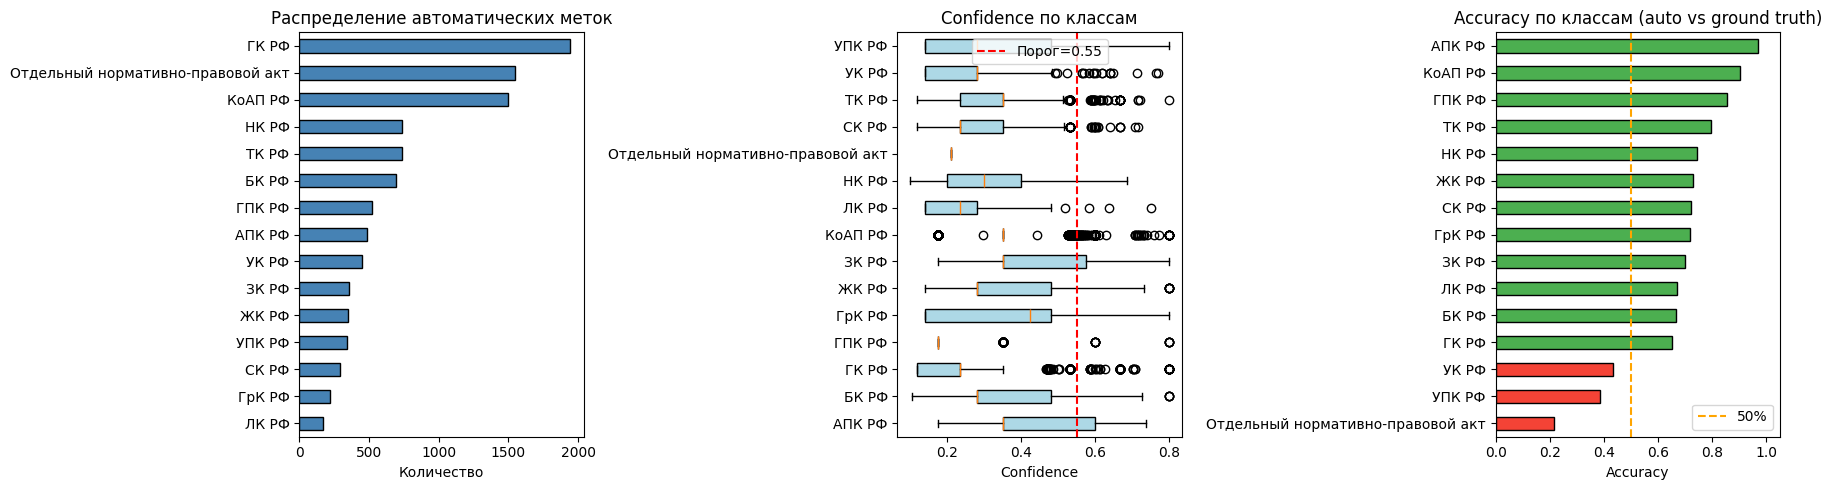

In [11]:
# Визуализация метрик
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Распределение меток
label_dist = pd.Series(metrics.label_distribution).sort_values(ascending=True)
label_dist.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Распределение автоматических меток')
axes[0].set_xlabel('Количество')

# 2) Confidence по классам (box-plot)
class_conf = df_labeled.groupby('auto_label')['confidence'].apply(list).to_dict()
class_names = sorted(class_conf.keys())
bp = axes[1].boxplot([class_conf[c] for c in class_names], vert=False, patch_artist=True,
                     labels=class_names)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
axes[1].axvline(agent.confidence_threshold, color='red', linestyle='--', label=f'Порог={agent.confidence_threshold}')
axes[1].set_title('Confidence по классам')
axes[1].set_xlabel('Confidence')
axes[1].legend()

# 3) Per-class accuracy
per_class_acc = {}
for label in sorted(df_labeled[TRUE_LABEL_COL].unique()):
    mask = df_labeled[TRUE_LABEL_COL] == label
    acc = (df_labeled.loc[mask, 'auto_label'] == label).mean()
    per_class_acc[label] = acc

acc_series = pd.Series(per_class_acc).sort_values()
colors_acc = ['#F44336' if v < 0.5 else '#4CAF50' for v in acc_series.values]
acc_series.plot(kind='barh', ax=axes[2], color=colors_acc, edgecolor='black')
axes[2].axvline(0.5, color='orange', linestyle='--', linewidth=1.5, label='50%')
axes[2].set_title('Accuracy по классам (auto vs ground truth)')
axes[2].set_xlabel('Accuracy')
axes[2].set_xlim(0, 1.05)
axes[2].legend()

plt.tight_layout()
plt.show()

---
## Часть 4: Экспорт в LabelStudio (export_to_labelstudio)

In [12]:
# Экспортируем в LabelStudio JSON
ls_path = agent.export_to_labelstudio(
    df_labeled,
    output_path=os.path.join('..', 'labelstudio_import.json'),
    text_column='content',
    label_column='auto_label'
)

# Проверяем JSON валидность
import json
with open(ls_path, 'r', encoding='utf-8') as f:
    ls_data = json.load(f)

print(f'\nJSON валиден: {len(ls_data)} задач')
print(f'\nПример задачи (первая):')
print(json.dumps(ls_data[0], ensure_ascii=False, indent=2)[:500])


Экспорт в LabelStudio: ..\labelstudio_import.json
  Экспортировано 10343 задач → ..\labelstudio_import.json

JSON валиден: 10343 задач

Пример задачи (первая):
{
  "id": 0,
  "data": {
    "text": "Статья 1. Осуществление правосудия арбитражными судами         Статья 1. Осуществление правосудия арбитражными судами   См. комментарии к статье 1 АПК РФ  Правосудие в сфере предпринимательской и иной экономической деятельности осуществляется арбитражными судами в Российской Федерации, образованными в соответствии с Конституцией Российской Федерации и федеральным конституционным законом (далее - арбитражные суды), путем разрешения экономических споро


---
## Часть 5: Сравнение с ручной разметкой однокурсника

Спецификация (`annotation_spec.md`) была передана однокурснику. Он разметил подвыборку — результаты в `annotation_disagreements.csv`.

Если файл ещё не готов, ячейка покажет сравнение авторазметки с ground truth из датасета.

In [13]:
human_labels_path = os.path.join('..', 'annotation_disagreements.csv')

if os.path.exists(human_labels_path):
    print('Файл с ручной разметкой найден. Сравниваю...')
    human_metrics = agent.compare_with_human(df_labeled, human_labels_path)
    if human_metrics:
        print(f"\nCohen's kappa (авто vs ручная): {human_metrics.kappa:.3f}")
        print(f'Percent agreement: {human_metrics.percent_agreement:.1f}%')
else:
    print('Файл annotation_disagreements.csv не найден.')
    print('Используем ground truth из датасета для демонстрации сравнения.\n')
    
    # Берём подвыборку (100 случайных примеров) для демонстрации
    np.random.seed(42)
    sample_idx = np.random.choice(len(df_labeled), size=min(100, len(df_labeled)), replace=False)
    sample_df = df_labeled.iloc[sample_idx].copy()
    sample_df['manual_label'] = sample_df[TRUE_LABEL_COL]  # Имитация ручной разметки
    
    sample_metrics = agent.check_quality(
        sample_df,
        auto_label_col='auto_label',
        ground_truth_col='manual_label'
    )
    
    if sample_metrics.kappa is not None:
        print(f"\nCohen's kappa на подвыборке: {sample_metrics.kappa:.3f}")
        print(f'Percent agreement: {sample_metrics.percent_agreement:.1f}%')

Файл с ручной разметкой найден. Сравниваю...

Сравнение с ручной разметкой: ..\annotation_disagreements.csv
  Файл должен содержать колонку 'manual_label'


---
## Бонус: Human-in-the-loop

Агент автоматически находит примеры с низкой уверенностью (confidence < threshold) и создаёт отдельный файл для ручной доразметки.

In [14]:
# Экспорт low-confidence примеров
low_conf_df = agent.export_low_confidence(
    df_labeled,
    output_path=os.path.join('..', 'low_confidence_review.csv'),
    text_column='content'
)

print(f'\nВсего low-confidence: {len(low_conf_df)}')
print(f'Порог: {agent.confidence_threshold}')

if len(low_conf_df) > 0:
    print('\nПримеры для ручной проверки (первые 5):')
    for i, (_, row) in enumerate(low_conf_df.head(5).iterrows()):
        text_preview = str(row['content'])[:120] + '...'
        print(f'  {i+1}. [{row["auto_label"]}] conf={row["confidence"]:.3f}')
        print(f'     {text_preview}')


Экспорт примеров с низкой уверенностью (<0.55)
  Экспортировано 9339 примеров → ..\low_confidence_review.csv
  Средн��я confidence: 0.258

Всего low-confidence: 9339
Порог: 0.55

Примеры для ручной проверки (первые 5):
  1. [НК РФ] conf=0.100
     Зарегистрирован в Минюсте РФ 24 декабря 2008 г.
  Регистрационный N 12968  В целях обеспечения организационно-методическ...
  2. [НК РФ] conf=0.100
     Государственная Дума Федерального Собрания Российской Федерации считает неприемлемыми любые посягательства на основопола...
  3. [НК РФ] conf=0.100
     Статья 1280.1. Использование правомерно обнародованных произведения литературы, изобразительного искусства, декоративно-...
  4. [НК РФ] conf=0.100
     Статья 1281. Срок действия исключительного права на произведение         Статья 1281. Срок действия исключительного пр...
  5. [НК РФ] conf=0.100
     Статья 1324. Исключительное право на фонограмму         Статья 1324. Исключительное право на фонограмму   См. Энциклопед...


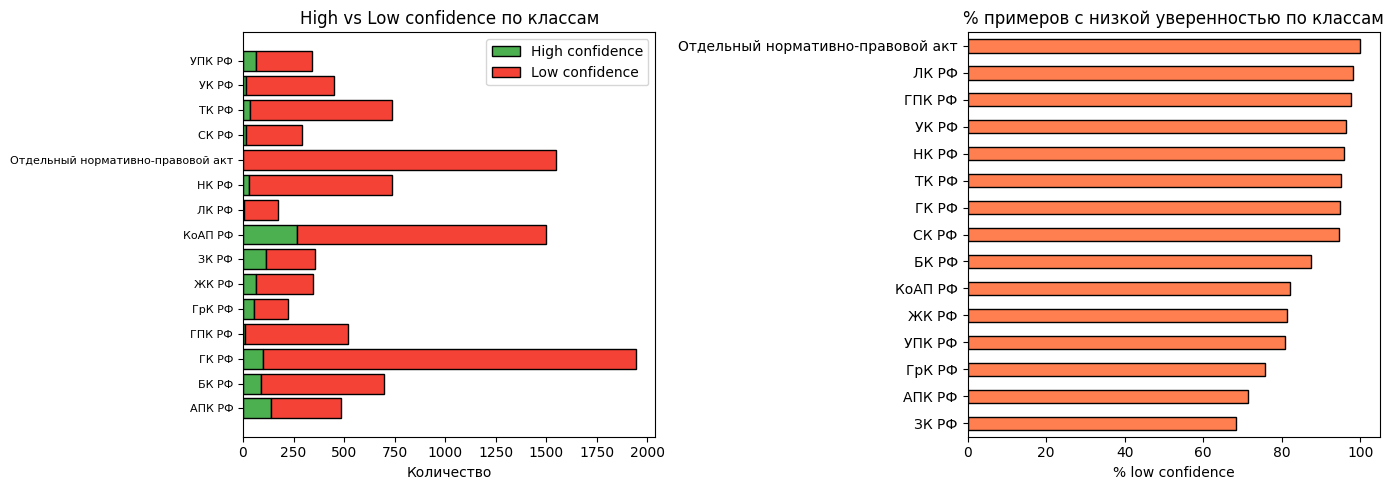

In [15]:
# Визуализация: low-confidence vs high-confidence по классам
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Количество low-confidence по классам
low_per_class = df_labeled[df_labeled['low_confidence']].groupby('auto_label').size()
high_per_class = df_labeled[~df_labeled['low_confidence']].groupby('auto_label').size()

all_labels_sorted = sorted(df_labeled['auto_label'].unique())
low_vals = [low_per_class.get(l, 0) for l in all_labels_sorted]
high_vals = [high_per_class.get(l, 0) for l in all_labels_sorted]

y_pos = np.arange(len(all_labels_sorted))
axes[0].barh(y_pos, high_vals, color='#4CAF50', label='High confidence', edgecolor='black')
axes[0].barh(y_pos, low_vals, left=high_vals, color='#F44336', label='Low confidence', edgecolor='black')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(all_labels_sorted, fontsize=8)
axes[0].set_title('High vs Low confidence по классам')
axes[0].set_xlabel('Количество')
axes[0].legend()

# Доля low-confidence по классам
total_per_class = df_labeled.groupby('auto_label').size()
low_pct = {l: low_per_class.get(l, 0) / total_per_class.get(l, 1) * 100 for l in all_labels_sorted}
pct_series = pd.Series(low_pct).sort_values(ascending=True)
pct_series.plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('% примеров с низкой уверенностью по классам')
axes[1].set_xlabel('% low confidence')

plt.tight_layout()
plt.show()

In [16]:
# Экспорт в LabelStudio только low-confidence (для ручной доразметки)
if len(low_conf_df) > 0:
    agent.export_to_labelstudio(
        df_labeled[df_labeled['low_confidence']],
        output_path=os.path.join('..', 'labelstudio_import_low_confidence.json'),
        text_column='content',
        label_column='auto_label'
    )
    print('Low-confidence задачи экспортированы в labelstudio_import_low_confidence.json')


Экспорт в LabelStudio: ..\labelstudio_import_low_confidence.json
  Экспортировано 9339 задач → ..\labelstudio_import_low_confidence.json
Low-confidence задачи экспортированы в labelstudio_import_low_confidence.json


---
## Сохранение результатов

In [17]:
# Сохраняем размеченный датасет
os.makedirs(os.path.join('..', 'results'), exist_ok=True)
output_path = os.path.join('..', 'results', 'legal_corpus_auto_labeled.csv')
df_labeled.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f'Размеченный датасет сохранён: {output_path}')
print(f'Размер: {df_labeled.shape}')

Размеченный датасет сохранён: ..\results\legal_corpus_auto_labeled.csv
Размер: (10343, 6)


---
## Итоговое резюме

### AnnotationAgent — реализованные скиллы

| Скилл | Метод | Описание |
|-------|-------|----------|
| Авторазметка | `auto_label(df)` | Гибридный метод: rule-based маркеры + TF-IDF zero-shot similarity |
| Спецификация | `generate_spec(df, task)` | Markdown: задача, 15 классов с определениями, 3+ примеров на класс, граничные случаи |
| Качество | `check_quality(df)` | Cohen's κ, percent agreement, распределение меток, confidence stats |
| LabelStudio | `export_to_labelstudio(df)` | JSON в формате LabelStudio import с predictions |
| Human-in-the-loop (бонус) | `export_low_confidence(df)` | CSV + LabelStudio JSON для примеров с confidence < threshold |
| Сравнение | `compare_with_human(df, path)` | Cohen's κ между авторазметкой и ручной разметкой |

### Покрытие требований

- **auto_label для text:** гибридный метод (rule-based + TF-IDF zero-shot)
- **Спецификация:** задача, 15 классов с определениями, 3+ примеров, 5 граничных случаев
- **Экспорт в LabelStudio:** валидный JSON
- **Cohen's κ + распределение меток + confidence:** `check_quality()`
- **Сравнение с однокурсником:** `compare_with_human()`
- **Бонус Human-in-the-loop:** `export_low_confidence()` + LabelStudio экспорт low-confidence